In [1635]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import re
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fcds-fall-25-deep-learning-assignment-1/sample_submission.csv
/kaggle/input/fcds-fall-25-deep-learning-assignment-1/songs_test.csv
/kaggle/input/fcds-fall-25-deep-learning-assignment-1/songs_train.csv


In [1636]:
train = pd.read_csv("/kaggle/input/fcds-fall-25-deep-learning-assignment-1/songs_train.csv")
test = pd.read_csv("/kaggle/input/fcds-fall-25-deep-learning-assignment-1/songs_test.csv")

In [1637]:
print(f"Shape of Training data: {train.shape}")
print(f"Shape of Test data: {test.shape}")

Shape of Training data: (26266, 24)
Shape of Test data: (6567, 23)


In [1638]:
train.head()

,id,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,0,7v71Aur70pf46NQIoSQii7,Knock You Out - Hardwell Remix,Bingo Players,0,7q5EDnr3FhMjwSMQciMqqH,Knock You Out (Remixes),6/17/2014,@deniceemoberg EDM - POP REMIXES,2fbrY1tuoW8Uji14H7623k,...,9,-3.967,0,0.0493,0.0373,0.005010,0.0829,0.215,128.039,386279
1,1,1oTHteQbmJw15rPxPVXUTv,Insane in the Brain,Cypress Hill,70,02lktkm4J7K7N8T63Gm7KX,Black Sunday,7/20/1993,90's Hip Hop Ultimate Collection,4IG024zoaGMurhTFBkMAv9,...,11,-10.489,1,0.2110,0.0297,0.186000,0.0894,0.767,102.305,208267
2,2,44evOHkEKmJ5VofpPo0ta9,Chill Cloud,Joan Ember,39,7Bopcb1Ld22bhXdzddvwot,Chill Cloud,1/10/2020,Charts 2020 🔥Top 2020🔥Hits 2020🔥Summer 2020🔥Po...,3xMQTDLOIGvj3lWH5e5x6F,...,7,-5.635,1,0.0688,0.1140,0.000000,0.2020,0.537,110.040,185466
3,3,2b6i9zx3ULzKrNWmyP0ePD,C90 (Remix),John C,78,16a33enqgAGsnuMmRH7uHa,C90 (Remix),12/18/2019,Trapperz,37i9dQZF1DWUmxBdWX3Pp4,...,1,-5.100,1,0.0937,0.3360,0.000002,0.0654,0.609,122.952,316000
4,4,6DrUHF3EWygcmQ0DIF8KP4,Te Olvidaré,MYA,67,4WTOdIQXRzSV6xCZbfKJna,Te Olvidaré,6/5/2019,Punto Tropical,37i9dQZF1DWZ1FUX6sM67g,...,7,-3.681,1,0.0671,0.0748,0.000000,0.3470,0.882,75.014,185415


In [1639]:
numerical_features = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = train.select_dtypes(include=['object']).columns.tolist()

In [1640]:
len(categorical_features)

10

In [1641]:
for feature in categorical_features:
    print(f"{feature}: {train[feature].nunique()} unique values")

track_id: 23205 unique values
track_name: 19601 unique values
track_artist: 9417 unique values
track_album_id: 18896 unique values
track_album_name: 16755 unique values
track_album_release_date: 4165 unique values
playlist_name: 449 unique values
playlist_id: 471 unique values
playlist_genre: 6 unique values
playlist_subgenre: 24 unique values


In [1642]:
train["track_album_release_date"].head()

0     6/17/2014
1     7/20/1993
2     1/10/2020
3    12/18/2019
4      6/5/2019
Name: track_album_release_date, dtype: object

In [1643]:
train['track_album_release_date'] = pd.to_datetime(train['track_album_release_date'], errors='coerce')
train['release_year'] = train['track_album_release_date'].dt.year
train['release_month'] = train['track_album_release_date'].dt.month
train['release_day'] = train['track_album_release_date'].dt.day

In [1644]:
train[['track_album_release_date', 'release_year', 'release_month', 'release_day']].head()

,track_album_release_date,release_year,release_month,release_day
0,2014-06-17,2014.0,6.0,17.0
1,1993-07-20,1993.0,7.0,20.0
2,2020-01-10,2020.0,1.0,10.0
3,2019-12-18,2019.0,12.0,18.0
4,2019-06-05,2019.0,6.0,5.0


In [1645]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26266 entries, 0 to 26265
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   id                        26266 non-null  int64         
 1   track_id                  26266 non-null  object        
 2   track_name                26262 non-null  object        
 3   track_artist              26262 non-null  object        
 4   track_popularity          26266 non-null  int64         
 5   track_album_id            26266 non-null  object        
 6   track_album_name          26262 non-null  object        
 7   track_album_release_date  24740 non-null  datetime64[ns]
 8   playlist_name             26266 non-null  object        
 9   playlist_id               26266 non-null  object        
 10  playlist_genre            26266 non-null  object        
 11  playlist_subgenre         26266 non-null  object        
 12  danceability      

In [1646]:
train[train[['track_album_release_date', 'release_year', 'release_month', 'release_day']].isnull().any(axis=1)]

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,id,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,release_year,release_month,release_day
14,14,4zXvB4MoQD8onk0NCZbeHG,Home Sweet Home,Mötley Crüe,70,18fYN6Hlig5t7ObBfQYUPe,Theatre of Pain,NaT,Nikki Sixx's Top Pixx,5d1arTPDEr76KMg9geDinZ,...,0.0354,0.09990,0.000003,0.1240,0.149,76.329,240933,NaN,NaN,NaN
30,30,29wJiSQcze8HEmxkUQykyp,Carrie,Europe,70,5Jkd47JEaCU1g4DcGBnHm3,The Final Countdown (Expanded Edition),NaT,Rock Ballads 80s 90s | Best Rock Love Songs 80...,0y8MUle9Lf8VDNjPsskzJB,...,0.0266,0.11300,0.000002,0.3580,0.139,136.596,272133,NaN,NaN,NaN
51,51,5UYPZZDQfpCE7A0FDDqv4k,Foreplay / Long Time,Boston,11,01OahkTPRCleDjobtRk7ST,Boston,NaT,Classic Rock Drive,37i9dQZF1DXdOEFt9ZX0dh,...,0.0541,0.00975,0.007480,0.0931,0.210,118.693,467640,NaN,NaN,NaN
59,59,2x1LQq8lsUzAA2wNj8yjC9,Pick Up the Pieces,Average White Band,53,5qZVqBEJSq2HkDMh2VCOQ6,AWB,NaT,The 1950s/1960s/1970s/1980s/1990s/2000s/2010s ...,1S7BckuYIkEazeNKOSM0uA,...,0.0427,0.05480,0.130000,0.0188,0.889,107.234,239908,NaN,NaN,NaN
102,102,7xo14jx9x5AQZtEHUY1OsA,Call That A Comeback,You Me At Six,0,4uC7zTuKQvssFjKEmLB8x3,Take Off Your Colours,NaT,Pop Punk | Post-Hardcore,1YgWQAs1s77NzieIH4ARKn,...,0.0735,0.00183,0.000000,0.3130,0.744,156.071,207267,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26216,26216,2VyOpoblI3AHO6R8dr87Ia,Never Had No One Ever - 2011 Remaster,The Smiths,48,5Y0p2XCgRRIjna91aQE8q7,The Queen Is Dead,NaT,permanent wave,7rPsfDTqiZYIT4PVzQ4c0c,...,0.0329,0.06790,0.002250,0.1430,0.336,194.625,218373,NaN,NaN,NaN
26217,26217,4KegtKX6D86OmNy8xCXsow,Pimp Tha Pen,DJ Screw,44,2F7xZ22zn1KZRlM4v6M9de,3 N The Mornin’ Part Two,NaT,3rd Coast Classics,1QJ66s6YBZgxMUaVUyrhbo,...,0.3340,0.07070,0.000000,0.4380,0.561,138.800,193560,NaN,NaN,NaN
26219,26219,5UVBumEwdUnzvqxrXOYLFA,17,Youth Lagoon,58,7jG32gfkuo10qarPgmWC7q,The Year of Hibernation,NaT,Ultimate Indie Presents... Best Indie Tracks o...,37i9dQZF1DWTHM4kX49UKs,...,0.0516,0.83500,0.654000,0.1290,0.120,74.517,236000,NaN,NaN,NaN
26226,26226,4BCmdMShfg9uz1WeyXaFae,Sister Golden Hair,America,48,64sDz3NRE1xYuaIZWAyu4N,America's Greatest Hits - History,NaT,70's Classic Rock,76lrxCrKrGDkDDf3SVPnl3,...,0.0344,0.14800,0.000225,0.1280,0.714,135.947,197227,NaN,NaN,NaN


In [1647]:
train.drop(columns='track_album_release_date', inplace=True)

In [1648]:
train["release_year"].min()

1957.0

In [1649]:
def extract_year_from_name(name):
    if isinstance(name, str):
        match = re.search(r'(19|20)\d{2}', name)
        if match:
            return int(match.group())
    return np.nan

train['year_from_name'] = train['track_name'].apply(extract_year_from_name)

In [1650]:
train['release_year'] = train['release_year'].fillna(train['year_from_name'])

In [1651]:
artist_year_median = train.groupby('track_artist')['release_year'].median()
train['release_year'] = train.apply(
    lambda row: artist_year_median[row['track_artist']] if pd.isna(row['release_year']) and row['track_artist'] in artist_year_median else row['release_year'],
    axis=1
)

In [1652]:
import matplotlib.pyplot as plt

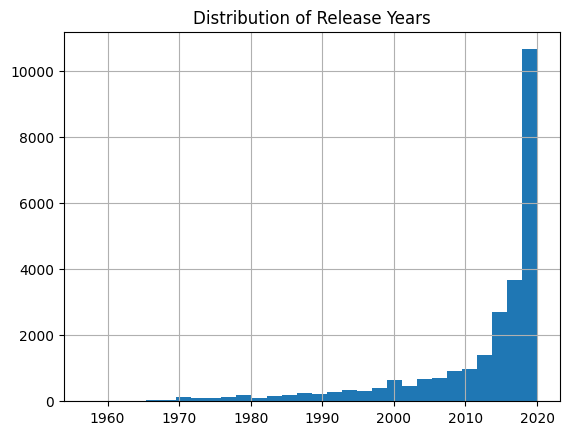

In [1653]:
train['release_year'].hist(bins=30)
plt.title("Distribution of Release Years")
plt.show()

In [1654]:
year_median = train['release_year'].median()

In [1655]:
train['release_year'] = train['release_year'].fillna(year_median)

In [1656]:
train.drop(columns=['release_month','release_day','year_from_name'], inplace=True)

In [1657]:
numerical_features = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = train.select_dtypes(include=['object']).columns.tolist()

In [1658]:
for feature in categorical_features:
    print(f"{feature}: {train[feature].nunique()} unique values")

track_id: 23205 unique values
track_name: 19601 unique values
track_artist: 9417 unique values
track_album_id: 18896 unique values
track_album_name: 16755 unique values
playlist_name: 449 unique values
playlist_id: 471 unique values
playlist_genre: 6 unique values
playlist_subgenre: 24 unique values


In [1659]:
duplicate_ids = train['track_id'][train['track_id'].duplicated(keep=False)]
duplicates = train[train['track_id'].isin(duplicate_ids)].sort_values(by='track_id')

In [1660]:
duplicates.head()

,id,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,playlist_name,playlist_id,playlist_genre,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,release_year
6516,6516,00Gu3RMpDW2vO9PjlMVFDL,Hide Away (feat. Envy Monroe),Blasterjaxx,42,5pqG85igfoeWcCDIsSi9x7,Hide Away (feat. Envy Monroe),Big Room EDM - by Spinnin' Records,7xWdFCrU5Gka6qp1ODrSdK,edm,...,-4.894,1,0.0421,0.0249,0.0,0.3610,0.134,130.001,188000,2019.0
24691,24691,00Gu3RMpDW2vO9PjlMVFDL,Hide Away (feat. Envy Monroe),Blasterjaxx,42,5pqG85igfoeWcCDIsSi9x7,Hide Away (feat. Envy Monroe),Epic Bass Drops | Best House Mixes,4IS7o1utOzhimFEFnj9gmu,edm,...,-4.894,1,0.0421,0.0249,0.0,0.3610,0.134,130.001,188000,2019.0
18446,18446,00QyLmjxaSEE8qIZQjBXBj,We Own It (Fast & Furious),2 Chainz,59,1jg2UPoSAr7CDPsEXcabo1,Fast & Furious 6,Today's Hits (Clean),7ENISpOJhocpMJVcGb0qcT,r&b,...,-4.573,1,0.4080,0.0521,0.0,0.0568,0.552,171.966,227893,2013.0
6450,6450,00QyLmjxaSEE8qIZQjBXBj,We Own It (Fast & Furious),2 Chainz,59,1jg2UPoSAr7CDPsEXcabo1,Fast & Furious 6,RAP Gangsta,1Z1gW89x4MSBjkvVjGg7DQ,rap,...,-4.573,1,0.4080,0.0521,0.0,0.0568,0.552,171.966,227893,2013.0
777,777,00QyLmjxaSEE8qIZQjBXBj,We Own It (Fast & Furious),2 Chainz,59,1jg2UPoSAr7CDPsEXcabo1,Fast & Furious 6,Locker Room,37i9dQZF1DX8SaiEt4OVJw,edm,...,-4.573,1,0.4080,0.0521,0.0,0.0568,0.552,171.966,227893,2013.0


In [1661]:
duplicate_names = train.groupby('track_name')['track_id'].nunique()
duplicate_names = duplicate_names[duplicate_names > 1].index

same_name_diff_id = train[train['track_name'].isin(duplicate_names)].sort_values(by='track_name')

In [1662]:
len(same_name_diff_id)

6999

In [1663]:
same_name_diff_id.head(10)

,id,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,playlist_name,playlist_id,playlist_genre,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,release_year
15874,15874,4xkOaSrkexMciUUogZKVTS,'Till I Collapse,Eminem,83,2cWBwpqMsDJC1ZUwz813lo,The Eminem Show,Locker Room,37i9dQZF1DX8SaiEt4OVJw,edm,...,-3.237,1,0.1860,0.06220,0.000000,0.0816,0.100,171.447,297787,2002.0
6316,6316,6yr8GiTHWvFfi4o6Q5ebdT,'Till I Collapse,Eminem,16,1ftvBBcu7jYIvXyt3JWB8S,The Eminem Show,Gangster Rap,5joQabz9ys3XPGbSx5CaKv,rap,...,-3.277,1,0.1970,0.07480,0.000000,0.0784,0.100,171.411,297893,2002.0
14013,14013,4xkOaSrkexMciUUogZKVTS,'Till I Collapse,Eminem,83,2cWBwpqMsDJC1ZUwz813lo,The Eminem Show,Gangster Rap | 100 % Gangster,2e0d7otcM1oyecfi3zZPWk,rap,...,-3.237,1,0.1860,0.06220,0.000000,0.0816,0.100,171.447,297787,2002.0
10542,10542,2NL4BBBSgypHnxUKmQdYcT,(Don't Fear) The Reaper,Blue Öyster Cult,10,6NNrQJ8ojvbfFzoUjjABo4,The Essential Blue Öyster Cult,70s Hard Rock,6pZlZ20vt3aDjIKw98aBtQ,rock,...,-8.349,1,0.0609,0.00127,0.002130,0.3050,0.559,141.162,308640,1990.5
23887,23887,5QTxFnGygVM4jFQiBovmRo,(Don't Fear) The Reaper,Blue Öyster Cult,75,6C9WzlQANeoD0GW5B41YJt,Agents Of Fortune,The Sound of Album Rock,3yj9YnQGTdnFuKbDyXGDi6,rock,...,-8.550,0,0.0733,0.00290,0.000211,0.2970,0.382,141.470,308120,1990.5
17884,17884,5QTxFnGygVM4jFQiBovmRo,(Don't Fear) The Reaper,Blue Öyster Cult,75,6C9WzlQANeoD0GW5B41YJt,Agents Of Fortune,Classic Rock Drive,37i9dQZF1DXdOEFt9ZX0dh,rock,...,-8.550,0,0.0733,0.00290,0.000211,0.2970,0.382,141.470,308120,1990.5
8256,8256,2NL4BBBSgypHnxUKmQdYcT,(Don't Fear) The Reaper,Blue Öyster Cult,10,6NNrQJ8ojvbfFzoUjjABo4,The Essential Blue Öyster Cult,Supernatural Classic Rock,6oghIlByD49KFGNmNU8GSH,rock,...,-8.349,1,0.0609,0.00127,0.002130,0.3050,0.559,141.162,308640,1990.5
19747,19747,3bkcq1VrFlcoqa04VBs4J8,(Feels Like) Heaven,Fiction Factory,45,345hZBqG7vIgLMHJcMZSZM,Throw the Warped Wheel Out,permanent wave,7rPsfDTqiZYIT4PVzQ4c0c,rock,...,-10.982,1,0.0512,0.19800,0.001720,0.0497,0.762,116.666,214047,1984.0
3445,3445,41Laec0pItedzpw2D8HWYp,(Feels Like) Heaven,Fiction Factory,57,04HMu1DvCSfkS5vqctgjUp,Throw The Warped Wheel Out,Permanent Wave CHDB,2foj4ZYVHRGqSd1aMqNPBj,rock,...,-10.978,1,0.0490,0.21400,0.003140,0.0521,0.719,116.659,213960,1984.0
10090,10090,2PzU4IB8Dr6mxV3lHuaG34,(I Can't Get No) Satisfaction - Mono Version,The Rolling Stones,76,2Q5MwpTmtjscaS34mJFXQQ,Out Of Our Heads,House Of The Rising Sun,1bMYfBHYBCRHY5LGkjlpSy,rock,...,-7.890,1,0.0338,0.03830,0.031700,0.1280,0.931,136.302,222813,1965.0


In [1664]:
popularity_per_id = train.groupby('track_id')['track_popularity'].nunique()
inconsistent_ids = popularity_per_id[popularity_per_id > 1].index

print(f"Number of inconsistent track_ids: {len(inconsistent_ids)}")

Number of inconsistent track_ids: 0


In [1665]:
duplicate_names = train.groupby('playlist_name')['playlist_id'].nunique()
duplicate_names = duplicate_names[duplicate_names > 1].index

same_name_diff_id = train[train['playlist_name'].isin(duplicate_names)].sort_values(by='playlist_name')

In [1666]:
len(same_name_diff_id)

1712

In [1667]:
same_name_diff_id.head(10)

,id,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,playlist_name,playlist_id,playlist_genre,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,release_year
15628,15628,70YPzqSEwJvAIQ6nMs1cjY,In Your Arms (with X Ambassadors),ILLENIUM,75,60xcVwuQJAOyu11xf9mObS,ASCEND,Dance Pop,37i9dQZF1DWZQaaqNMbbXa,pop,...,-4.750,1,0.0496,0.19800,0.000000,0.1140,0.112,148.036,220730,2019.0
7011,7011,3Kuu5vASpXK8oRsxOvau6P,Think About You,Kygo,71,5vZy4cohzmdhOUGCdsUNpt,Think About You,Dance Pop,37i9dQZF1DWZQaaqNMbbXa,pop,...,-7.891,1,0.0354,0.16600,0.000000,0.1100,0.190,123.969,208567,2019.0
11523,11523,2IDHoSlbG0CKH9rhq68wTb,Say My Name (feat. Zyra) - RAC Mix,ODESZA,47,7Eg6srmG6BVIEiUmiRjzI4,Say My Name Remixes,Dance Pop,37i9dQZF1DWZQaaqNMbbXa,pop,...,-8.446,1,0.0451,0.02500,0.056000,0.0616,0.477,115.002,243091,2014.0
1439,1439,6XqvFyJGdUD5IWee02ARKU,Polaroid,Jonas Blue,16,6x8gRx7RDvPckYBzPodW8w,Blue,Dance Pop,37i9dQZF1DWZQaaqNMbbXa,pop,...,-4.481,0,0.0361,0.29000,0.000000,0.0730,0.472,114.043,193377,2018.0
15554,15554,22mek4IiqubGD9ctzxc69s,How Deep Is Your Love,Calvin Harris,77,3cG32DOXJoYlOHMmJIaQsm,How Deep Is Your Love,Dance Pop,37i9dQZF1DWZQaaqNMbbXa,pop,...,-4.373,0,0.0731,0.03890,0.001710,0.3880,0.336,122.003,212640,2015.0
24979,24979,1xK7enJZVdv37fnnxoZlPq,With You,Kaskade,71,03Rd91m56yw4XklwHF9FHq,With You,Dance Pop,37i9dQZF1DWZQaaqNMbbXa,pop,...,-3.815,0,0.4860,0.12300,0.000000,0.1900,0.529,172.191,180840,2019.0
4429,4429,6F1kPSgdnlSzZRfskE9vaV,Lions in the Wild,Martin Garrix,2,39GUANQpkDHusLAAJPPS7z,Lions in the Wild,Dance Pop,0B2HdP15IucgE0vk3sluJR,pop,...,-6.810,0,0.0442,0.00434,0.000000,0.8160,0.280,127.854,211890,2016.0
1322,1322,2M1mqcNUBIAfRoD2Puhejf,Carry Me Home (feat. Jake Reese),KSHMR,64,102DnoxN7Wrs46tdgNI080,Carry Me Home (feat. Jake Reese),Dance Pop,0B2HdP15IucgE0vk3sluJR,pop,...,-4.104,0,0.0599,0.01400,0.000037,0.0870,0.484,128.029,191250,2018.0
7632,7632,1ahVFh0ViDZr8LvkEVlq3B,No Sleep (feat. Bonn),Martin Garrix,76,7KJTuTXYSnBGNgAxte3CSg,No Sleep (feat. Bonn),Dance Pop,37i9dQZF1DWZQaaqNMbbXa,pop,...,-6.385,1,0.0326,0.12900,0.000000,0.1210,0.327,128.133,207095,2019.0
12029,12029,2JoIjuzRplpYGvvLpSW2on,Sad Song (feat. TINI),Alesso,72,0D26ZmfHtg7309j2TEKxnR,Sad Song (feat. TINI),Dance Pop,37i9dQZF1DWZQaaqNMbbXa,pop,...,-6.474,1,0.0361,0.08780,0.000000,0.3410,0.550,110.021,154024,2019.0


In [1668]:
duplicate_names = train.groupby('track_album_name')['track_album_id'].nunique()
duplicate_names = duplicate_names[duplicate_names > 1].index

same_name_diff_id = train[train['track_album_name'].isin(duplicate_names)].sort_values(by='track_album_name')

In [1669]:
len(same_name_diff_id)

5571

In [1670]:
import seaborn as sns

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

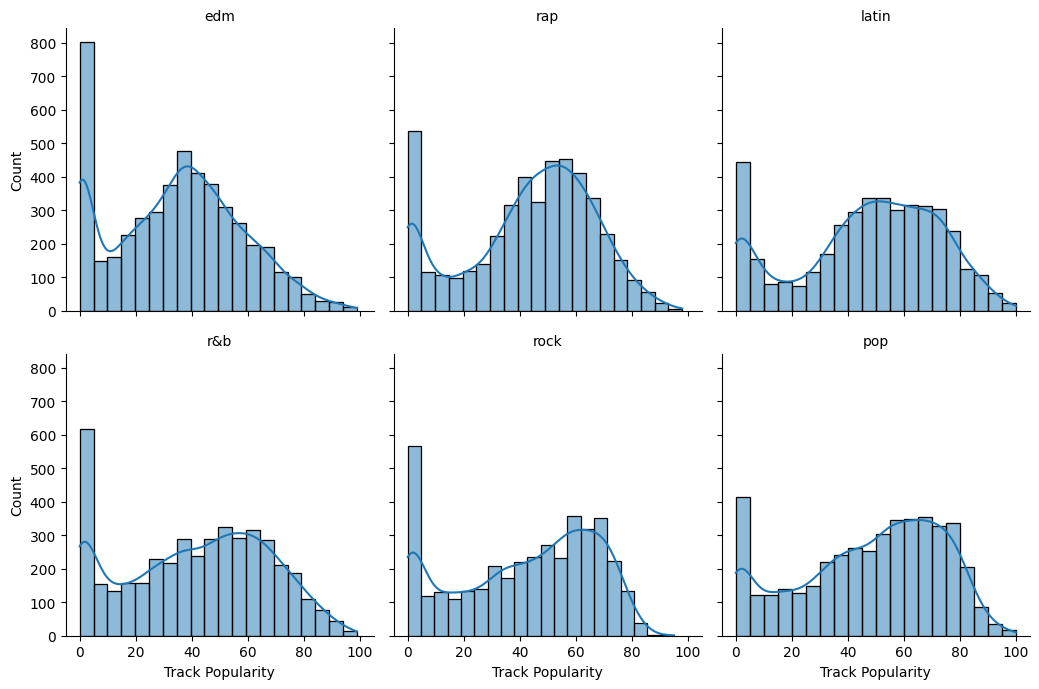

In [1671]:
g = sns.FacetGrid(train, col='playlist_genre', col_wrap=3, height=3.5, sharex=True, sharey=True)
g.map_dataframe(sns.histplot, x='track_popularity', bins=20, kde=True)
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Track Popularity", "Count")
plt.show()

In [1672]:
train[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
id,26266.0,13132.500000,7582.485421,0.00000,6566.25000,13132.500000,19698.750000,26265.000
track_popularity,26266.0,42.476548,24.988980,0.00000,24.00000,45.000000,62.000000,100.000
danceability,26266.0,0.655060,0.145619,0.00000,0.56300,0.672000,0.761000,0.983
energy,26266.0,0.698625,0.181348,0.00814,0.58100,0.721000,0.840000,1.000
key,26266.0,5.368461,3.614363,0.00000,2.00000,6.000000,9.000000,11.000
loudness,26266.0,-6.716584,2.981640,-46.44800,-8.16675,-6.172000,-4.646250,1.275
mode,26266.0,0.563809,0.495921,0.00000,0.00000,1.000000,1.000000,1.000
speechiness,26266.0,0.107074,0.101050,0.00000,0.04110,0.062800,0.132000,0.918
acousticness,26266.0,0.175271,0.219955,0.00000,0.01520,0.080400,0.253000,0.992
instrumentalness,26266.0,0.085822,0.225556,0.00000,0.00000,0.000017,0.004978,0.994


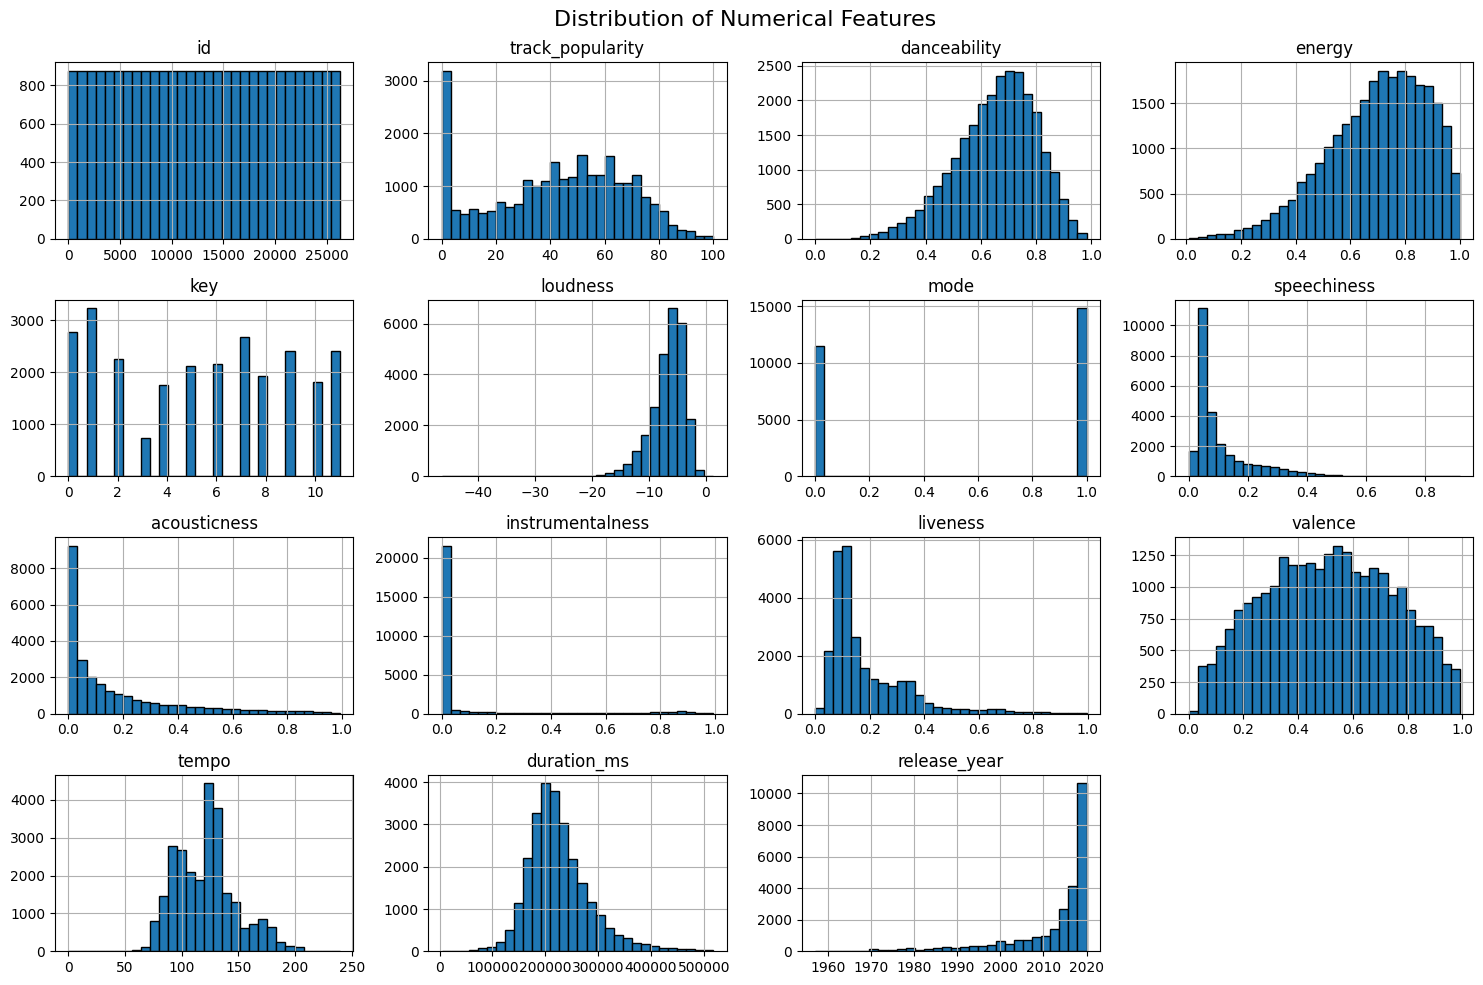

In [1673]:
train[numerical_features].hist(figsize=(15, 10), bins=30, edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

In [1609]:
corr = train[numerical_features].corr()
corr

,id,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,release_year
id,1.000000,-0.010117,-0.005528,0.006052,-0.001122,0.001841,-0.002133,0.001780,0.000701,0.006547,0.003730,-0.001778,-0.006792,0.004453,-0.002821
track_popularity,-0.010117,1.000000,0.067506,-0.114806,0.005669,0.053600,0.005944,0.004364,0.083998,-0.148256,-0.058992,0.031354,-0.010153,-0.141427,0.065635
danceability,-0.005528,0.067506,1.000000,-0.086281,0.009022,0.023153,-0.060085,0.182114,-0.026412,-0.007680,-0.122069,0.333787,-0.180703,-0.099615,0.150874
energy,0.006052,-0.114806,-0.086281,1.000000,0.009901,0.678482,-0.001482,-0.033599,-0.541774,0.034936,0.161204,0.151582,0.151789,0.013949,0.025318
key,-0.001122,0.005669,0.009022,0.009901,1.000000,0.000752,-0.173488,0.022432,-0.002593,0.005767,0.004973,0.019228,-0.013253,0.014927,0.005142
loudness,0.001841,0.053600,0.023153,0.678482,0.000752,1.000000,-0.011653,0.010770,-0.369738,-0.148518,0.077446,0.055373,0.095576,-0.111452,0.257430
mode,-0.002133,0.005944,-0.060085,-0.001482,-0.173488,-0.011653,1.000000,-0.065426,0.009942,-0.008308,-0.003883,0.006388,0.015964,0.014778,-0.080964
speechiness,0.001780,0.004364,0.182114,-0.033599,0.022432,0.010770,-0.065426,1.000000,0.027974,-0.102551,0.052595,0.068773,0.044455,-0.088692,0.090524
acousticness,0.000701,0.083998,-0.026412,-0.541774,-0.002593,-0.369738,0.009942,0.027974,1.000000,-0.003515,-0.078343,-0.018566,-0.113622,-0.079866,0.017986
instrumentalness,0.006547,-0.148256,-0.007680,0.034936,0.005767,-0.148518,-0.008308,-0.102551,-0.003515,1.000000,0.001720,-0.177984,0.022799,0.056376,0.088378


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


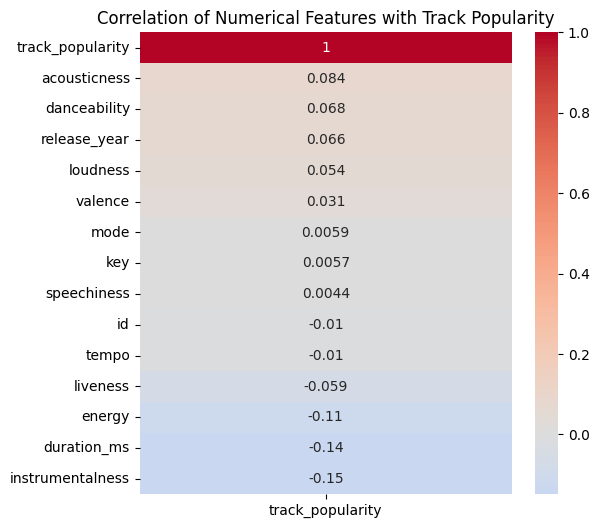

In [1674]:
target_corr = corr[['track_popularity']].sort_values(by='track_popularity', ascending=False)

plt.figure(figsize=(6, len(target_corr) * 0.4))
sns.heatmap(target_corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation of Numerical Features with Track Popularity")
plt.show()

In [1675]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26266 entries, 0 to 26265
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 26266 non-null  int64  
 1   track_id           26266 non-null  object 
 2   track_name         26262 non-null  object 
 3   track_artist       26262 non-null  object 
 4   track_popularity   26266 non-null  int64  
 5   track_album_id     26266 non-null  object 
 6   track_album_name   26262 non-null  object 
 7   playlist_name      26266 non-null  object 
 8   playlist_id        26266 non-null  object 
 9   playlist_genre     26266 non-null  object 
 10  playlist_subgenre  26266 non-null  object 
 11  danceability       26266 non-null  float64
 12  energy             26266 non-null  float64
 13  key                26266 non-null  int64  
 14  loudness           26266 non-null  float64
 15  mode               26266 non-null  int64  
 16  speechiness        262

In [1676]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6567 entries, 0 to 6566
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        6567 non-null   int64  
 1   track_id                  6567 non-null   object 
 2   track_name                6566 non-null   object 
 3   track_artist              6566 non-null   object 
 4   track_album_id            6567 non-null   object 
 5   track_album_name          6566 non-null   object 
 6   track_album_release_date  6567 non-null   object 
 7   playlist_name             6567 non-null   object 
 8   playlist_id               6567 non-null   object 
 9   playlist_genre            6567 non-null   object 
 10  playlist_subgenre         6567 non-null   object 
 11  danceability              6567 non-null   float64
 12  energy                    6567 non-null   float64
 13  key                       6567 non-null   int64  
 14  loudness

In [1677]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [1678]:
X = train.drop(columns=['track_popularity'])
y = train['track_popularity']

In [1679]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26266 entries, 0 to 26265
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 26266 non-null  int64  
 1   track_id           26266 non-null  object 
 2   track_name         26262 non-null  object 
 3   track_artist       26262 non-null  object 
 4   track_album_id     26266 non-null  object 
 5   track_album_name   26262 non-null  object 
 6   playlist_name      26266 non-null  object 
 7   playlist_id        26266 non-null  object 
 8   playlist_genre     26266 non-null  object 
 9   playlist_subgenre  26266 non-null  object 
 10  danceability       26266 non-null  float64
 11  energy             26266 non-null  float64
 12  key                26266 non-null  int64  
 13  loudness           26266 non-null  float64
 14  mode               26266 non-null  int64  
 15  speechiness        26266 non-null  float64
 16  acousticness       262

In [1680]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 26266 entries, 0 to 26265
Series name: track_popularity
Non-Null Count  Dtype
--------------  -----
26266 non-null  int64
dtypes: int64(1)
memory usage: 205.3 KB


In [1689]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [1690]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


In [1691]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [1692]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

In [1693]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization

In [1697]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_processed.shape[1],)),
    BatchNormalization(),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dense(1)
])

In [1698]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_42 (Dense)                │ (None, 128)            │     9,538,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,550,081 (36.43 MB)

 Trainable params: 9,549,633 (36.43 MB)

 Non-trainable params: 448 (1.75 KB)

In [1699]:
history = model.fit(
    X_train_processed, y_train,
    validation_data=(X_val_processed, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 47s 65ms/step - loss: 1996.5203 - mae: 39.5258 - val_loss: 618.0616 - val_mae: 21.5081
Epoch 2/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 41s 63ms/step - loss: 299.3033 - mae: 14.2048 - val_loss: 283.5623 - val_mae: 12.4133
Epoch 3/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 41s 63ms/step - loss: 76.4114 - mae: 6.7413 - val_loss: 259.0520 - val_mae: 11.6651
Epoch 4/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 42s 63ms/step - loss: 53.1436 - mae: 5.6228 - val_loss: 258.1125 - val_mae: 11.5338
Epoch 5/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 41s 63ms/step - loss: 42.7514 - mae: 5.0455 - val_loss: 257.0049 - val_mae: 11.4858
Epoch 6/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 41s 63ms/step - loss: 38.7859 - mae: 4.8475 - val_loss: 256.5405 - val_mae: 11.1925
Epoch 7/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 41s 63ms/step - loss: 33.4160 - mae: 4.5475 - val_loss: 254.6370 - val_mae: 11.2975
Epoch 8/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 42s 64ms/step - loss: 34.3533 - mae: 4.5908 - val_loss: 262.1597 - val_mae: 11.1806
Epo

In [1700]:
test['track_album_release_date'].head()

0     1/1/1988
1     6/7/2019
2    3/21/2006
3     7/2/2018
4         1994
Name: track_album_release_date, dtype: object

In [1701]:
test.columns = test.columns.str.strip()

In [1702]:
test['release_year'] = pd.to_datetime(
    test['track_album_release_date'],
    errors='coerce',
    infer_datetime_format=True
).dt.year

/tmp/ipykernel_37/3584947484.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  test['release_year'] = pd.to_datetime(


In [1703]:
mask_missing = test['release_year'].isna()
test.loc[mask_missing, 'release_year'] = test.loc[mask_missing, 'track_album_release_date'].str.extract(r'(\d{4})').astype(float)

In [1704]:
test['release_year'] = test['release_year'].fillna(train['release_year'].median()).astype(int)

In [1707]:
X_test_processed = preprocessor.transform(test)
test_predictions = model.predict(X_test_processed)
test_predictions[:10]

206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step


array([[59.179756],
       [74.41134 ],
       [14.193299],
       [43.68849 ],
       [56.28482 ],
       [47.82155 ],
       [64.59305 ],
       [59.456745],
       [ 5.558407],
       [67.85997 ]], dtype=float32)

In [1709]:
submission = pd.DataFrame({
    'id': test['id'],
    'target': test_predictions.flatten()
})

In [1710]:
submission

,id,target
0,0,59.179756
1,1,74.411339
2,2,14.193299
3,3,43.688492
4,4,56.284821
...,...,...
6562,6562,44.710930
6563,6563,27.497177
6564,6564,52.822025
6565,6565,8.300692
